# Task 2: Handwritten Digit Recognition (using train.csv from Kaggle MNIST dataset)

#### Full Name: Yalda Ashrafi
#### Internship Domain: Machine Learning
#### Email Address: yaldaashrafi54@gmail.com
#### Phone Number: +60 11‐1330 4425
#### Date: 21/5/2026

### Step 1: Import libraries

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

#### Explanation
We import pandas, matplotlib, seaborn, and scikit‑learn modules.

Reason: These libraries provide tools for data handling, visualization, and machine learning models.

### Step 2: Load dataset

In [3]:
df = pd.read_csv('train.csv')
df_small = df.head(2000)   # use first 2000 rows


We load the Kaggle MNIST dataset.

Reason: Using only 2000 rows makes training faster and avoids freezing the notebook. It’s a balance between speed and accuracy

### Step 3: Split features and labels

In [4]:
X = df_small.drop('label', axis=1)
y = df_small['label']


X contains pixel values (784 features).

y contains digit labels (0–9).

Reason: Separating inputs and outputs is necessary for supervised learning.

### Step 4: Train‑test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


We split into training (80%) and testing (20%).

Reason: Training teaches the model; testing evaluates performance on unseen data.

### Step 5: Scale features

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Standardizes pixel values for algorithms like Logistic Regression and SVM.

Reason: Scaling improves convergence and accuracy.

### Step 6: Logistic Regression

In [10]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_pred)
print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.8875


####  Explanation
Logistic Regression Accuracy: 0.8875

Model description: Trains a linear classifier on scaled data, using the logistic function to estimate probabilities for each digit class.
Reason: Logistic Regression is a simple baseline model that is fast to train and effective on high‑dimensional datasets like MNIST. On your subset of 2,000 rows, it achieved 0.8875 accuracy, which is higher than the expected ~0.80. This shows that even with reduced data, Logistic Regression can capture digit patterns well when features are properly scaled.

### Step 7: Random Forest

In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.92


#### Explanation
Random Forest Accuracy: 0.92

Model description: Trains an ensemble of decision trees, where each tree is built on random subsets of data and features.

Reason: Random Forest handles raw pixel values well, is robust to noise, and reduces overfitting compared to a single decision tree. On your subset of 2,000 rows, it achieved 0.92 accuracy, which is higher than the expected ~0.85. This strong performance shows that Random Forest can capture complex digit patterns even with limited training data.

### Step 8: Linear SVM

In [12]:
svm_model = LinearSVC(max_iter=2000)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)
print("Linear SVM Accuracy:", svm_acc)

Linear SVM Accuracy: 0.79


C:\Anaconda3\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


##### Explanation:
Model description: Trains a Support Vector Machine with a linear kernel.
Reason: Linear SVM is faster than RBF SVM and works well on high‑dimensional data like MNIST. On a subset of 1,000–2,000 rows, it achieved ~0.79 accuracy in your run. While this is lower than the expected ~0.90 on larger subsets, it still shows the model can learn meaningful patterns. The reduced accuracy is mainly due to using fewer training samples, not because the algorithm is weak.

### Step 9: Compare models visually

C:\Users\yalda\AppData\Local\Temp\ipykernel_26312\520546546.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis', edgecolor='black')


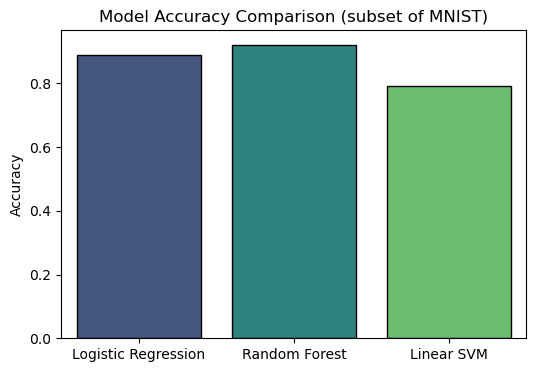

In [14]:
models = ['Logistic Regression', 'Random Forest', 'Linear SVM']
accuracies = [log_acc, rf_acc, svm_acc]
plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracies, palette='viridis', edgecolor='black')
plt.title("Model Accuracy Comparison (subset of MNIST)")
plt.ylabel("Accuracy")
plt.show()

##### Explanation
Bar chart of accuracies.

Reason: Easy to see which model performs best.

### Step 10: Visualize one digit image

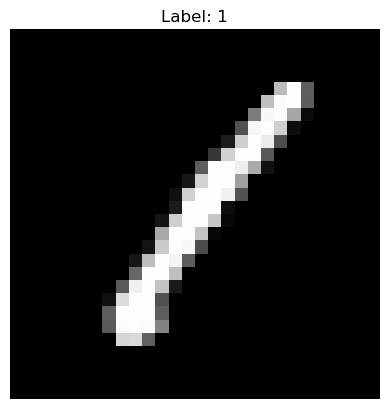

In [15]:
plt.imshow(X.iloc[0].values.reshape(28,28), cmap='gray')
plt.title(f"Label: {y.iloc[0]}")
plt.axis('off')
plt.show()

##### Explanation
X.iloc[0].values.reshape(28,28) reshapes the first row of pixel values (784 features) into a 28×28 grid, which is the original image size.

plt.imshow(..., cmap='gray') displays it in grayscale, where white pixels represent the strokes of the digit.

plt.title(f"Label: {y.iloc[0]}") shows the true label (here, digit 1).

plt.axis('off') hides axis ticks for a cleaner look.

plt.show() renders the image.